Imported libraries

In [1]:
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize

Settings used in the analysis

In [2]:
COUNTS_PER_CELL = 10_000
N_GENES_KEPT = 2000
N_COMPONENTS = 50
K_GRID = [2, 5, 10, 15, 20, 30, 50]
MIN_VALIDATION_GAIN = 0.01

Downloading the dataset and converting it to a cell-by-gene count matrix

In [3]:
import os
import urllib.request
import h5py

LOOM_URL = "https://raw.githubusercontent.com/YosefLab/scVI-data/master/retina.loom"
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
if not os.path.exists("data/retina.loom"):
    urllib.request.urlretrieve(LOOM_URL, "data/retina.loom")

with h5py.File("data/retina.loom", "r") as loom:
    matrix = loom["matrix"]
    blocks = [sp.csr_matrix(matrix[start:start + 1000])
              for start in range(0, matrix.shape[0], 1000)]
    loom_batch = loom["col_attrs/BatchID"][:].ravel().astype(int)
    loom_cluster = loom["col_attrs/ClusterID"][:].ravel().astype(int)

counts_cells_by_genes = sp.csr_matrix(sp.vstack(blocks).T, dtype=np.float32)
sp.save_npz("data/retina_counts.npz", counts_cells_by_genes)
pd.DataFrame({"batch": loom_batch, "cluster": loom_cluster}).to_csv(
    "data/retina_labels.csv", index=False)
print(counts_cells_by_genes.shape, counts_cells_by_genes.nnz)

(19829, 13166) 17379142


Reading the count matrix and cell labels

In [4]:
counts = sp.csr_array(sp.load_npz("data/retina_counts.npz"))
labels = pd.read_csv("data/retina_labels.csv")
batch = labels["batch"].to_numpy()
cluster = labels["cluster"].to_numpy()
n_cells, n_genes = counts.shape

Cells per cluster and batch + counts and detected genes per cell

In [5]:
cluster_by_batch = pd.crosstab(cluster, batch)
umis_per_cell = counts.sum(axis=1)
genes_per_cell = (counts > 0).sum(axis=1)

splitting cells into training, validation and test splits

In [6]:
train_idx, rest_idx = train_test_split(np.arange(n_cells), test_size=0.3,
                                       stratify=cluster, random_state=0)
val_idx, test_idx = train_test_split(rest_idx, test_size=0.5,
                                     stratify=cluster[rest_idx], random_state=0)

Normalizing each cell to 10k counts and taking log

In [7]:
counts_per_10k = normalize(counts, norm="l1") * COUNTS_PER_CELL
log_counts_per_10k = counts_per_10k.log1p()

Dispersion of every gene on a set of cells

In [8]:
def gene_dispersion(fit_idx):
    fit_cells = counts_per_10k[fit_idx]
    gene_mean = fit_cells.mean(axis=0)
    gene_second_moment = fit_cells.power(2).mean(axis=0)
    gene_var = gene_second_moment - gene_mean ** 2
    expressed = gene_mean > 0
    dispersion = np.full(n_genes, -np.inf)
    dispersion[expressed] = gene_var[expressed] / gene_mean[expressed]
    return gene_mean, dispersion

Selecting the 2000 most dispersed genes 

In [9]:
gene_mean, dispersion = gene_dispersion(train_idx)
kept_genes = np.argsort(dispersion)[-N_GENES_KEPT:]
top_mean_genes = gene_mean.argsort()[-N_GENES_KEPT:]
dense = log_counts_per_10k[:, kept_genes].toarray()

Standardising each gene with the training mean and standard deviation

In [10]:
scaler = StandardScaler().fit(dense[train_idx])
x_train = scaler.transform(dense[train_idx])
x_val = scaler.transform(dense[val_idx])
x_test = scaler.transform(dense[test_idx])

Fitting PCA with 50 components 

In [11]:
pca = PCA(n_components=N_COMPONENTS, random_state=0)
pca.fit(x_train)
explained = pca.explained_variance_ratio_

Reconstruction error when only the first k components are kept

In [12]:
def reconstruction_error(pca, x, k):
    scores = pca.transform(x)
    scores[:, k:] = 0
    x_hat = pca.inverse_transform(scores)
    return float(np.mean((x - x_hat) ** 2))

In [13]:
def per_k(errors):
    return dict(zip(K_GRID, errors.tolist()))

Training and validation error over the k grid

In [14]:
train_err = np.array([reconstruction_error(pca, x_train, k) for k in K_GRID])
val_err = np.array([reconstruction_error(pca, x_val, k) for k in K_GRID])
train_err0 = reconstruction_error(pca, x_train, 0)
val_err0 = reconstruction_error(pca, x_val, 0)
step_gain = 1 - val_err[1:] / val_err[:-1]
val_gain = dict(zip(K_GRID[1:], step_gain.tolist()))
k_star = min(k for k, gain in val_gain.items() if gain < MIN_VALIDATION_GAIN)
k_star_pos = K_GRID.index(k_star)

Overall test error at the chose k*

In [15]:
test_err = reconstruction_error(pca, x_test, k_star)

Repeating gene selection, scaling and PCA on batch 0 and scoring batch 1

In [16]:
batch0_idx = np.flatnonzero(batch == 0)
batch1_idx = np.flatnonzero(batch == 1)
batch_gene_mean, batch_dispersion = gene_dispersion(batch0_idx)
batch_genes = np.argsort(batch_dispersion)[-N_GENES_KEPT:]
batch_dense = log_counts_per_10k[:, batch_genes].toarray()
batch_scaler = StandardScaler().fit(batch_dense[batch0_idx])
x_batch0 = batch_scaler.transform(batch_dense[batch0_idx])
x_batch1 = batch_scaler.transform(batch_dense[batch1_idx])
batch_pca = PCA(n_components=N_COMPONENTS, random_state=0)
batch_pca.fit(x_batch0)
batch0_err = np.array([reconstruction_error(batch_pca, x_batch0, k) for k in K_GRID])
batch1_err = np.array([reconstruction_error(batch_pca, x_batch1, k) for k in K_GRID])
batch0_err0 = reconstruction_error(batch_pca, x_batch0, 0)
batch1_err0 = reconstruction_error(batch_pca, x_batch1, 0)

Writing every number the report quotes to results.json

In [17]:
results = {"n_cells": n_cells, "n_genes": n_genes, "count_min": float(counts.min()),
    "count_max": float(counts.max()),
    "fraction_nonzero": counts.nnz / (n_cells * n_genes),
    "umis_per_cell_min_median_max": np.percentile(umis_per_cell, [0, 50, 100]).tolist(),
    "genes_per_cell_min_median_max": np.percentile(genes_per_cell, [0, 50, 100]).tolist(),
    "cells_per_cluster": cluster_by_batch.sum(axis=1).tolist(),
    "cells_per_batch": cluster_by_batch.sum(axis=0).tolist(),
    "cluster_by_batch": cluster_by_batch.values.tolist(),
    "n_train": len(train_idx), "n_validation": len(val_idx), "n_test": len(test_idx),
    "n_genes_kept": N_GENES_KEPT, "n_components_fitted": N_COMPONENTS, "k_grid": K_GRID,
    "gene_selection_rule": "the 2,000 genes with the largest dispersion (variance divided "
                           "by mean of the counts normalised to 10,000 per cell, before "
                           "log1p) on the training cells; genes with zero mean excluded",
    "n_genes_zero_mean_on_train": int((gene_mean == 0).sum()),
    "n_genes_zero_mean_on_batch0": int((batch_gene_mean == 0).sum()),
    "dispersion_cut_off": float(dispersion[kept_genes].min()),
    "kept_in_top_2000_by_mean": int(np.isin(kept_genes, top_mean_genes).sum()),
    "train_error": per_k(train_err), "validation_error": per_k(val_err),
    "max_gap_train_val_over_grid": float(np.abs(val_err - train_err).max()),
    "validation_gain_per_step": val_gain,
    "k_star_rule": "smallest grid k whose validation gain over the previous grid point "
                   "is below 1 %", "k_star": k_star,
    "errors_at_k_star_train_val_test": [train_err[k_star_pos], val_err[k_star_pos], test_err],
    "test_error_at_k_star_only": test_err,
    "explained_variance_ratio_pc1_pc2": explained[:2].tolist(),
    "cumulative_variance_ratio_k_star_and_50": explained.cumsum()[[k_star - 1, -1]].tolist(),
    "error_at_k0_train": train_err0, "error_at_k0_validation": val_err0,
    "batch0_fit_error": per_k(batch0_err), "batch1_heldout_error": per_k(batch1_err),
    "error_at_k_star_batch0_fit": batch0_err[k_star_pos],
    "error_at_k_star_batch1_heldout": batch1_err[k_star_pos],
    "batch1_over_batch0_ratio_at_k_star": batch1_err[k_star_pos] / batch0_err[k_star_pos],
    "error_at_k0_batch0": batch0_err0, "error_at_k0_batch1": batch1_err0,
    "batch1_own_variance": float(np.mean(x_batch1.var(axis=0))),
    "batch1_mean_shift_squared": float(np.mean(x_batch1.mean(axis=0) ** 2)),
    "relative_error_reduction_at_k_star_batch0_batch1": [
        1 - batch0_err[k_star_pos] / batch0_err0, 1 - batch1_err[k_star_pos] / batch1_err0]}
with open("results.json", "w") as file:
    json.dump(results, file, indent=1)
print(f"k* = {k_star}, results written to results.json")

k* = 15, results written to results.json


Visuals for the results

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [19]:
plt.rcParams.update({"font.size": 8.5, "axes.labelsize": 9, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.ymargin": 0.10, "lines.markersize": 5, "xtick.minor.visible": False,
    "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.pad_inches": 0.02})
BATCH_COLOURS = [(0.16, 0.50, 0.50), (0.78, 0.30, 0.58)]
CLUSTER_COLOURS = plt.cm.tab10.colors + plt.cm.tab20b.colors[::4]
NEAR_BLACK = "0.13"
MID_GREY = "0.62"
PALE_GREY = "0.79"
GUIDE_GREY = "0.73"
TEXT_GREY = "0.33"
RED = (0.77, 0.31, 0.32)
LEGEND_ABOVE = dict(loc="lower right", bbox_to_anchor=(1.0, 1.02), frameon=False,
                    borderaxespad=0, handlelength=0.8, handletextpad=0.4,
                    columnspacing=0.6)
RING = dict(mec="white", mew=0.6)

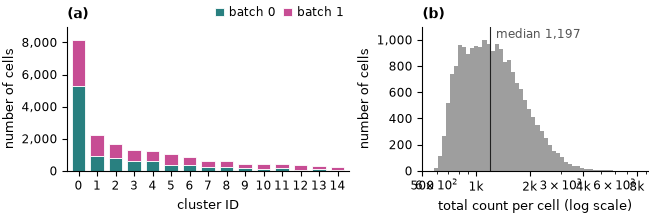

In [20]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(6.54, 2.20), layout="constrained",
                                 gridspec_kw={"width_ratios": [1.25, 1]})
cluster_by_batch.plot.bar(stacked=True, ax=ax_a, rot=0, width=0.72, ec="white", lw=0.6,
                          color=BATCH_COLOURS, title="(a)", xlabel="cluster ID",
                          ylabel="number of cells")
ax_a.legend(["batch 0", "batch 1"], ncol=2, **LEGEND_ABOVE)
umi_median = np.median(umis_per_cell)
ax_b.axvline(umi_median, color=NEAR_BLACK, lw=0.8)
ax_b.hist(umis_per_cell, color=MID_GREY,
          bins=np.geomspace(umis_per_cell.min(), umis_per_cell.max(), 51))
ax_b.set(xscale="log", xticks=[500, 1000, 2000, 4000, 8000], title="(b)",
         xticklabels=["500", "1k", "2k", "4k", "8k"], ylabel="number of cells",
         xlabel="total count per cell (log scale)")
ax_b.text(umi_median * 1.08, 0.99, f"median {umi_median:,.0f}", va="top",
          color=TEXT_GREY, transform=ax_b.get_xaxis_transform())
for ax in (ax_a, ax_b):
    ax.yaxis.set_major_formatter("{x:,.0f}")
fig.savefig("figures/fig1_eda.png")

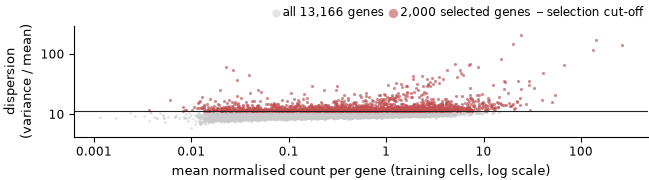

In [21]:
expressed = gene_mean > 0
MEAN_TICKS = [0.001, 0.01, 0.1, 1, 10, 100]
DISP_TICKS = [10, 100]
fig, ax = plt.subplots(figsize=(6.54, 1.85), layout="constrained")
ax.scatter(gene_mean[expressed], dispersion[expressed], s=4, color=PALE_GREY, alpha=0.5,
           lw=0, label=f"all {n_genes:,} genes")
ax.scatter(gene_mean[kept_genes], dispersion[kept_genes], s=5, color=RED, alpha=0.6,
           lw=0, label=f"{N_GENES_KEPT:,} selected genes")
ax.axhline(dispersion[kept_genes].min(), color=NEAR_BLACK, lw=0.8, label="selection cut-off")
ax.set(xscale="log", xlabel="mean normalised count per gene (training cells, log scale)",
       yscale="log", ylabel="dispersion\n(variance / mean)", xticks=MEAN_TICKS,
       xticklabels=[f"{t:g}" for t in MEAN_TICKS], yticks=DISP_TICKS,
       yticklabels=[str(t) for t in DISP_TICKS])
ax.minorticks_off()
ax.legend(ncol=3, markerscale=3, **{**LEGEND_ABOVE, "handlelength": 0.4})
fig.savefig("figures/fig2_feature_selection.png")

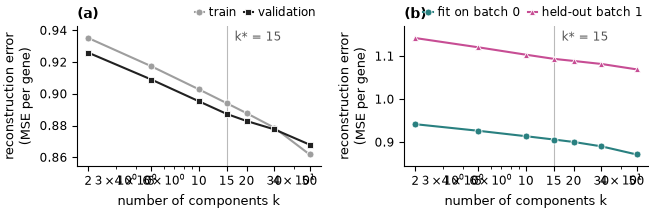

In [22]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(6.54, 2.15), layout="constrained")
fig.get_layout_engine().set(wspace=0.05)
ax_a.plot(K_GRID, train_err, "o-", color=MID_GREY, label="train", **RING)
ax_a.plot(K_GRID, val_err, "s-", color=NEAR_BLACK, label="validation", **RING)
ax_b.plot(K_GRID, batch0_err, "o-", color=BATCH_COLOURS[0], label="fit on batch 0",
          **RING)
ax_b.plot(K_GRID, batch1_err, "^-", color=BATCH_COLOURS[1], label="held-out batch 1",
          **RING)
for ax, letter, ncol in ((ax_a, "(a)", 2), (ax_b, "(b)", 2)):
    ax.set(xscale="log", xticks=K_GRID, xticklabels=[str(k) for k in K_GRID],
           title=letter, xlabel="number of components k",
           ylabel="reconstruction error\n(MSE per gene)")
    ax.text(k_star * 1.12, 0.97, f"k* = {k_star}", transform=ax.get_xaxis_transform(),
            va="top", color=TEXT_GREY)
    ax.legend(ncol=ncol, **LEGEND_ABOVE)
    ax.axvline(k_star, color=GUIDE_GREY, lw=0.8, zorder=0)
fig.savefig("figures/fig3_model_selection.png")

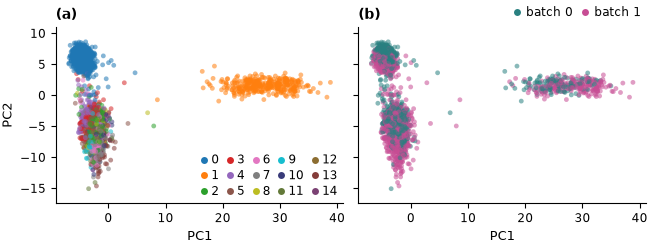

In [23]:
val_scores = pca.transform(x_val)
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(6.54, 2.50), sharey=True,
                                 layout="constrained")
by_cluster = ax_a.scatter(val_scores[:, 0], val_scores[:, 1], s=12, alpha=0.55, lw=0,
                          c=cluster[val_idx], cmap=ListedColormap(CLUSTER_COLOURS))
by_batch = ax_b.scatter(val_scores[:, 0], val_scores[:, 1], s=12, alpha=0.55, lw=0,
                        c=batch[val_idx], cmap=ListedColormap(BATCH_COLOURS))
ax_a.set(xlabel="PC1", ylabel="PC2", title="(a)")
ax_b.set(xlabel="PC1", title="(b)")
ax_a.legend(*by_cluster.legend_elements(num=None, alpha=1), ncol=5, loc="lower right",
            frameon=False, handlelength=0.6, handletextpad=0.3, columnspacing=0.6,
            labelspacing=0.25, borderaxespad=0.05)
ax_b.legend(by_batch.legend_elements(alpha=1)[0], ["batch 0", "batch 1"], ncol=2,
            **LEGEND_ABOVE)
fig.savefig("figures/fig4_pc_scatter.png", pil_kwargs={"optimize": True})